# 📊 Exploratory Data Analysis – PJM Energy Consumption

## Objective
Analyze energy consumption patterns to:
- Understand seasonality (hourly, daily, monthly)
- Detect anomalies and outliers
- Identify trends for forecasting

Dataset: PJM Hourly Energy Consumption


In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
plt.style.use("ggplot")

In [2]:
#Loading the dataset
df = pd.read_csv("../data/raw/PJME_hourly.csv")

df.columns = [col.lower() for col in df.columns]
df.rename(columns={"pjme_mw": "value"}, inplace=True)

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

df.head()

,datetime,value
8734,2002-01-01 01:00:00,30393.0
8735,2002-01-01 02:00:00,29265.0
8736,2002-01-01 03:00:00,28357.0
8737,2002-01-01 04:00:00,27899.0
8738,2002-01-01 05:00:00,28057.0


In [3]:
#Basic Info
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()
df.describe()

Shape: (145366, 2)

Columns: Index(['datetime', 'value'], dtype='str')
<class 'pandas.DataFrame'>
Index: 145366 entries, 8734 to 140254
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  145366 non-null  datetime64[us]
 1   value     145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.3 MB


,datetime,value
count,145366,145366.000000
mean,2010-04-18 03:25:25.999202,32080.222831
min,2002-01-01 01:00:00,14544.000000
25%,2006-02-23 14:15:00,27573.000000
50%,2010-04-18 04:30:00,31421.000000
75%,2014-06-10 18:45:00,35650.000000
max,2018-08-03 00:00:00,62009.000000
std,NaN,6464.012166


In [4]:
#Checking for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 datetime    0
value       0
dtype: int64


**Observation:**  
Dataset contains no significant missing values.

In [5]:
#Checking for Duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


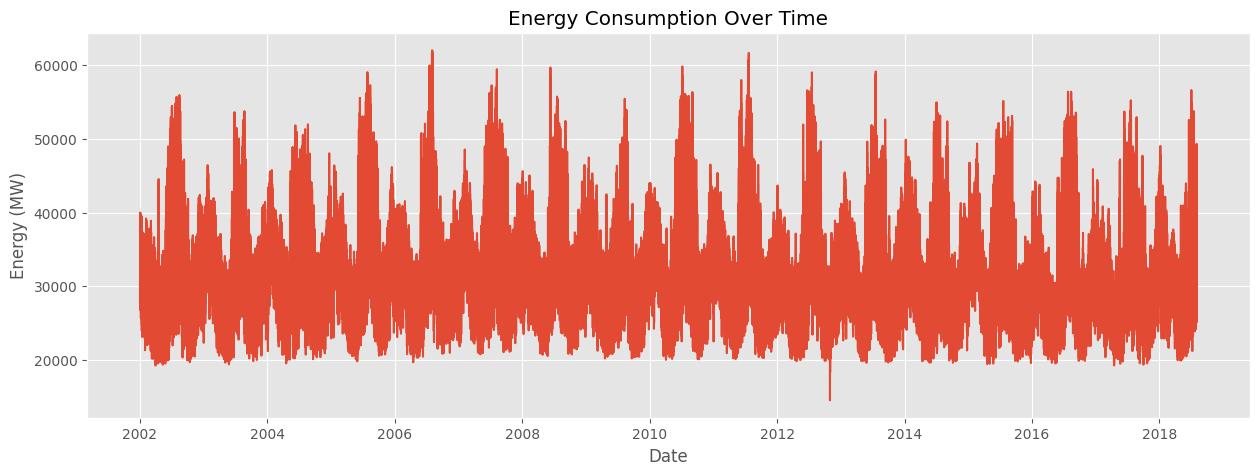

In [6]:
#Time series plot
plt.figure(figsize=(15,5))
plt.plot(df['datetime'], df['value'])
plt.title("Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy (MW)")
plt.show()

**Insight:**  
Clear long-term trends and repeating seasonal patterns are visible.

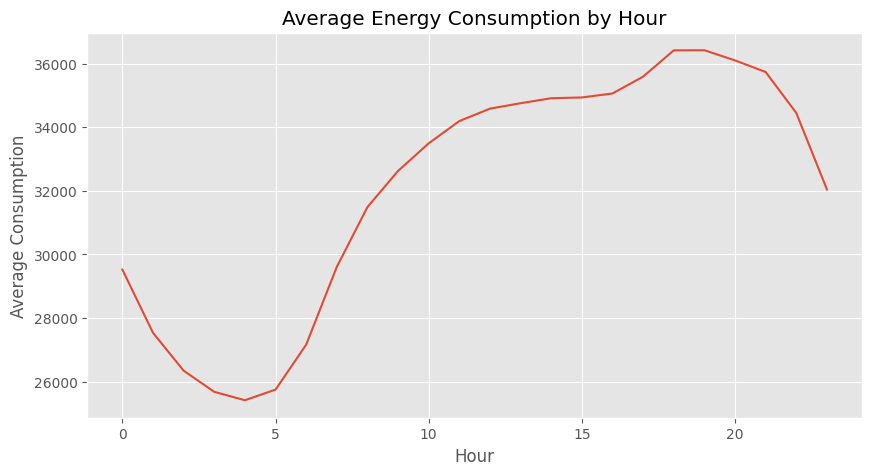

In [7]:
# Hourly pattern
df['hour'] = df['datetime'].dt.hour

df.groupby('hour')['value'].mean().plot(figsize=(10,5))
plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Consumption")
plt.show()

**Insight:**  
Energy demand follows a daily cycle with peaks during active hours.

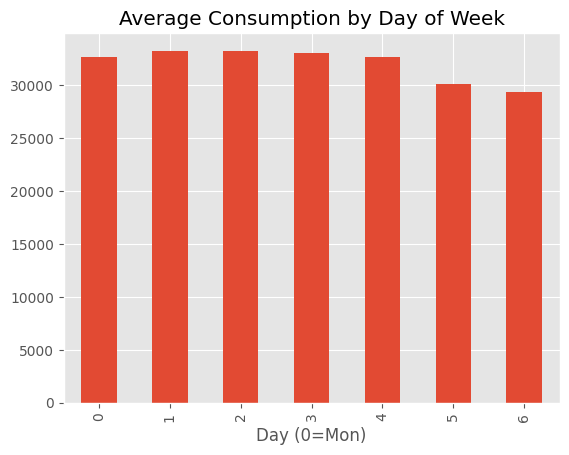

In [8]:
# Weekly pattern
df['dayofweek'] = df['datetime'].dt.dayofweek

df.groupby('dayofweek')['value'].mean().plot(kind='bar')
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.show()

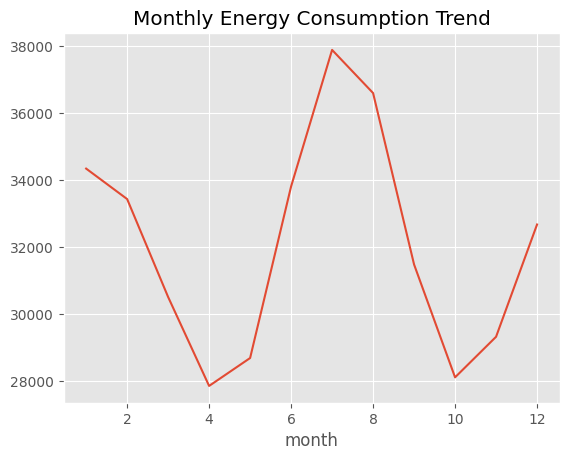

In [9]:
# Monthly Trend (Seasonality)
df['month'] = df['datetime'].dt.month

df.groupby('month')['value'].mean().plot()
plt.title("Monthly Energy Consumption Trend")
plt.show()

**Insight:**  
Seasonal variation observed – higher usage in summer/winter months.

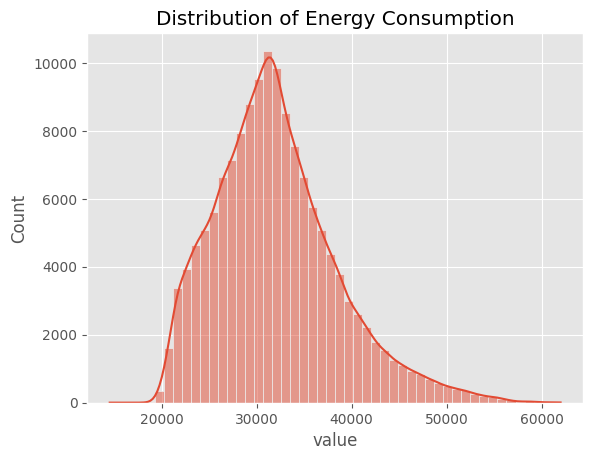

In [ ]:
# Distribution Plot
 

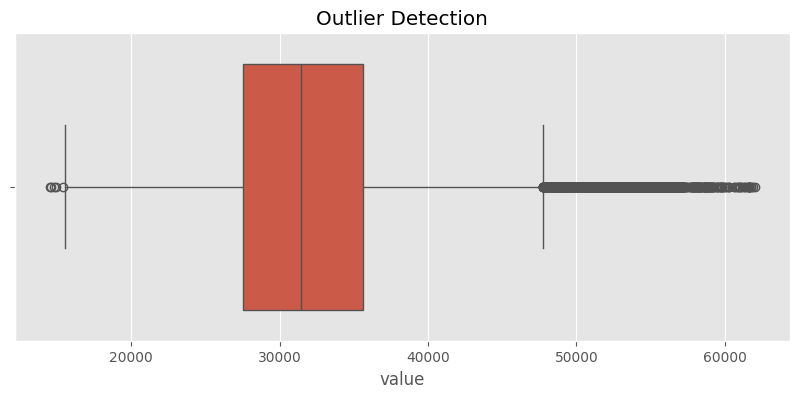

In [11]:
# Outlier Detection (Boxplot)
plt.figure(figsize=(10,4))
sns.boxplot(x=df['value'])
plt.title("Outlier Detection")
plt.show()

**Insight:**  
Extreme values exist but likely represent real demand spikes (e.g., heatwaves), not noise.

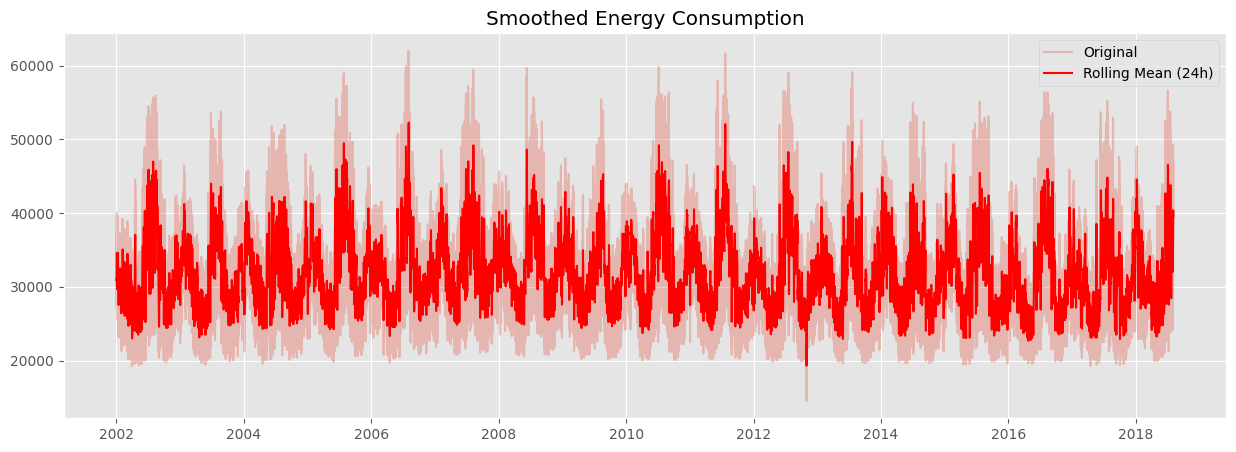

In [12]:
# Rolling Mean (Trend Smoothing)
df['rolling_mean_24'] = df['value'].rolling(24).mean()

plt.figure(figsize=(15,5))
plt.plot(df['datetime'], df['value'], alpha=0.3, label='Original')
plt.plot(df['datetime'], df['rolling_mean_24'], color='red', label='Rolling Mean (24h)')
plt.legend()
plt.title("Smoothed Energy Consumption")
plt.show()

## 🔍 Key Insights

- Strong hourly seasonality observed
- Weekly usage patterns vary between weekdays and weekends
- Clear seasonal trends across months (summer & winter peaks)
- Outliers correspond to real-world demand spikes
- Data is clean with minimal preprocessing required

## 🚀 Next Step
Proceed to feature engineering and model training.

## 🎯 Feature Engineering Decisions

Based on EDA:

- **Hourly patterns observed** → Added `hour`, `hour_sin`, `hour_cos`
- **Weekly trends detected** → Added `dayofweek`
- **Seasonal trends identified** → Added `month`, `dayofyear`
- **Temporal dependency observed** → Added lag features (1, 24, 168)
- **Trend smoothing required** → Added rolling statistics
- **Extreme spikes observed** → Kept outliers as they represent real events